# Exercise 6 Digitization and Data Analytics 

In [49]:
!pip install torch torchvision torchaudio "torch"

zsh:1: command not found: pip


## Deep Learning

Content

- Introduction
- Fundamental concepts in interaction with Torch
- Design, training, and learning of a simple neural network

### Introduction
Basic explanation of a neural network model in Keras: https://towardsdatascience.com/building-a-deep-learning-model-using-keras-1548ca149d37.

The operations during training and usage of neural networks are done on matrices. Thus, you should be familiar with the necessary concepts of Linear Algebra.

If you need a brush up:
- https://www.youtube.com/watch?v=fNk_zzaMoSs&list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab
- https://www.youtube.com/watch?v=7UJ4CFRGd-U&list=PLE7DDD91010BC51F8

### Preparation
We will use Torch within this notebook, but also introduce you to underlying concepts which should be helpful to switch frameworks if needed.

Make sure, that plot_lib.py is in the same directory as your notebook.

In [50]:
import torch
import torch.nn as nn
import numpy as np
import random
import math
from plot_lib import set_default, show_scatterplot, plot_bases, plot_data
from IPython import display

#### Matrix operations

Note : Python 3 also supports matrix multiplication using a special operater "@"

In [51]:
x = np.array([1, 1, 1])
y = np.array([1, 1, 1])

In [52]:
x@y

np.int64(3)

**Exercise**: If you are not familiar with matrice operations, do the following:
- Run a simple vector x vector multiplication.
- Run a simple vector x matrix multiplication. 
- Run a Matrix x Matrix multiplication.

In [53]:
# --- Exercise: Matrix Operations ---

# Vector x Vector multiplication (dot product)
v1 = torch.tensor([1.0, 2.0, 3.0])
v2 = torch.tensor([4.0, 5.0, 6.0])
dot_product = torch.dot(v1, v2)
print("Vector x Vector:")
print(f"{v1} . {v2} = {dot_product}\n")

# Vector x Matrix multiplication
v = torch.tensor([1.0, 2.0])
M = torch.tensor([[3.0, 4.0], 
                  [5.0, 6.0]])
vec_mat_mult = torch.matmul(v, M) # or v @ M
print("Vector x Matrix:")
print(f"{v} @ \n{M}\n= {vec_mat_mult}\n")

# Matrix x Matrix multiplication
M1 = torch.tensor([[1.0, 2.0], 
                   [3.0, 4.0]])
M2 = torch.tensor([[5.0, 6.0], 
                   [7.0, 8.0]])
mat_mat_mult = torch.matmul(M1, M2) # or M1 @ M2
print("Matrix x Matrix:")
print(f"{M1} @ \n{M2}\n= \n{mat_mat_mult}")

Vector x Vector:
tensor([1., 2., 3.]) . tensor([4., 5., 6.]) = 32.0

Vector x Matrix:
tensor([1., 2.]) @ 
tensor([[3., 4.],
        [5., 6.]])
= tensor([13., 16.])

Matrix x Matrix:
tensor([[1., 2.],
        [3., 4.]]) @ 
tensor([[5., 6.],
        [7., 8.]])
= 
tensor([[19., 22.],
        [43., 50.]])


### Neural Networks
You find a basic explanation of Neural Network models in Keras here:
- https://towardsdatascience.com/building-a-deep-learning-model-using-keras-1548ca149d37

How to interpret the deep learning operations? It is basically a rotation of n-dimensional vectors followed by a non-linearity (which allows the vector to "bend"). 

Please use the links above if the intuition of the above statement is lacking.

In [54]:
set_default()

In [55]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In order to visualize the operations within a neural network, we randomly generate a 
set of 2-D data and present the in a plot.

In [56]:
# generate some points in 2-D space
n_points = 1000
X = torch.randn(n_points, 2).to(device)
colors = X[:, 0]

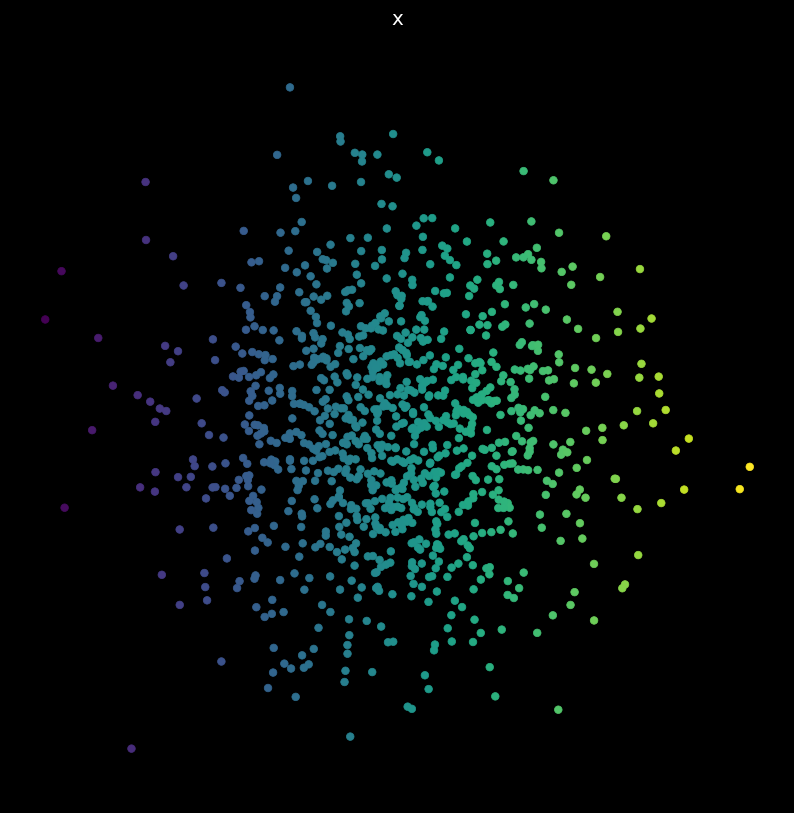

In [57]:
show_scatterplot(X, colors, title='x')

**Exercise**: In the following, a simple neural network is defined, and the resulting data 
    points are plotted.
- Change the activation function in order to see its impact on the data. 

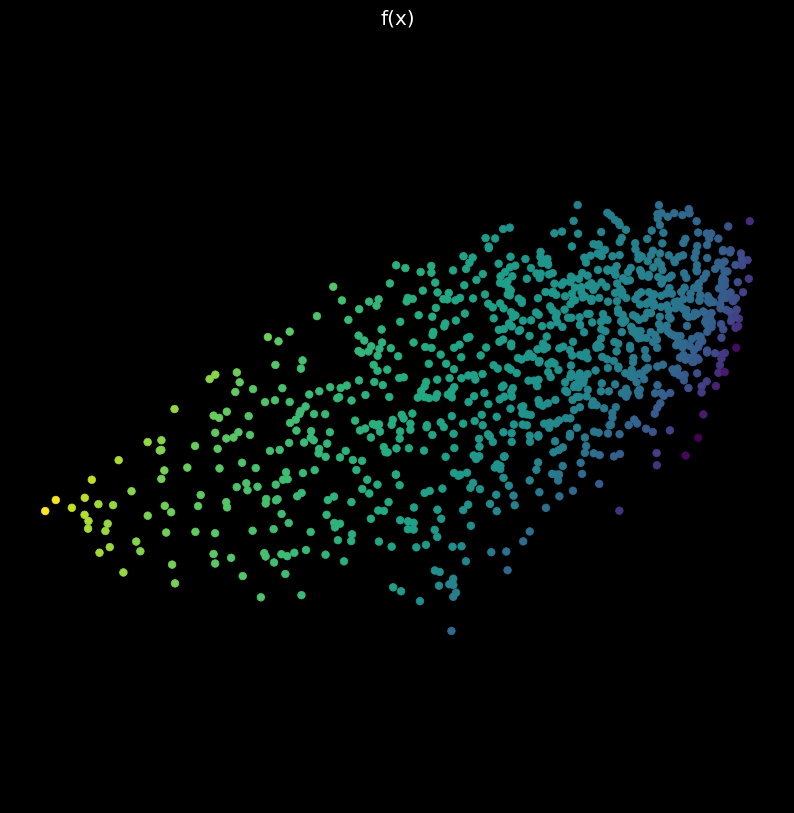

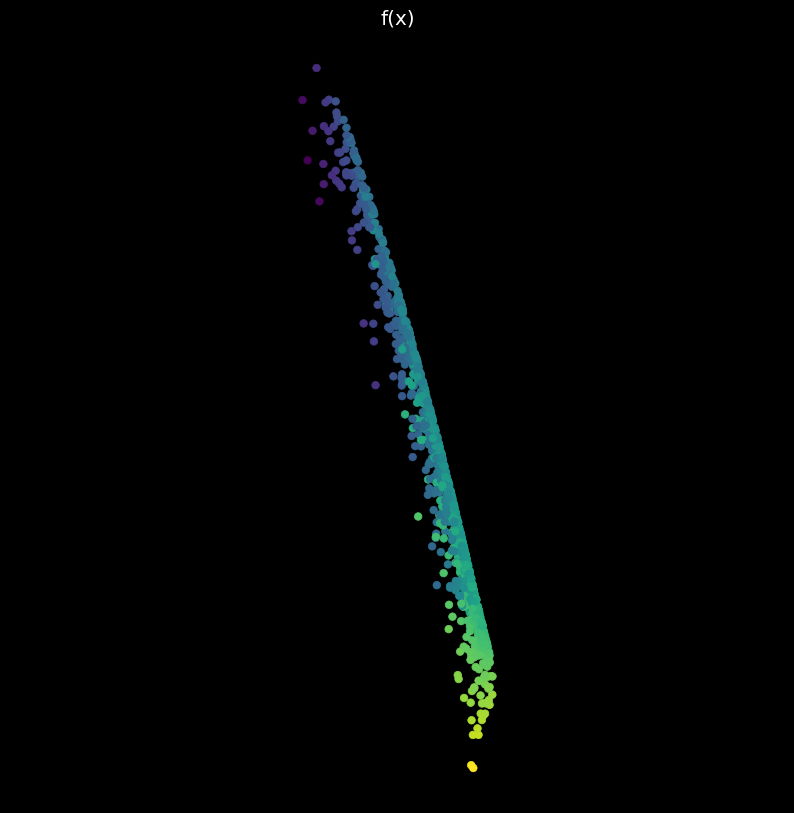

In [58]:
n_hidden = 5

# NL = nn.ReLU()
NL = nn.Tanh()

for i in range(2):
    # create 1-layer neural networks with random weights
    model = nn.Sequential(
            nn.Linear(2, n_hidden), 
            NL, 
            nn.Linear(n_hidden, 2)
        )
    model.to(device)
    with torch.no_grad():
        Y = model(X)
    show_scatterplot(Y, colors, title='f(x)')

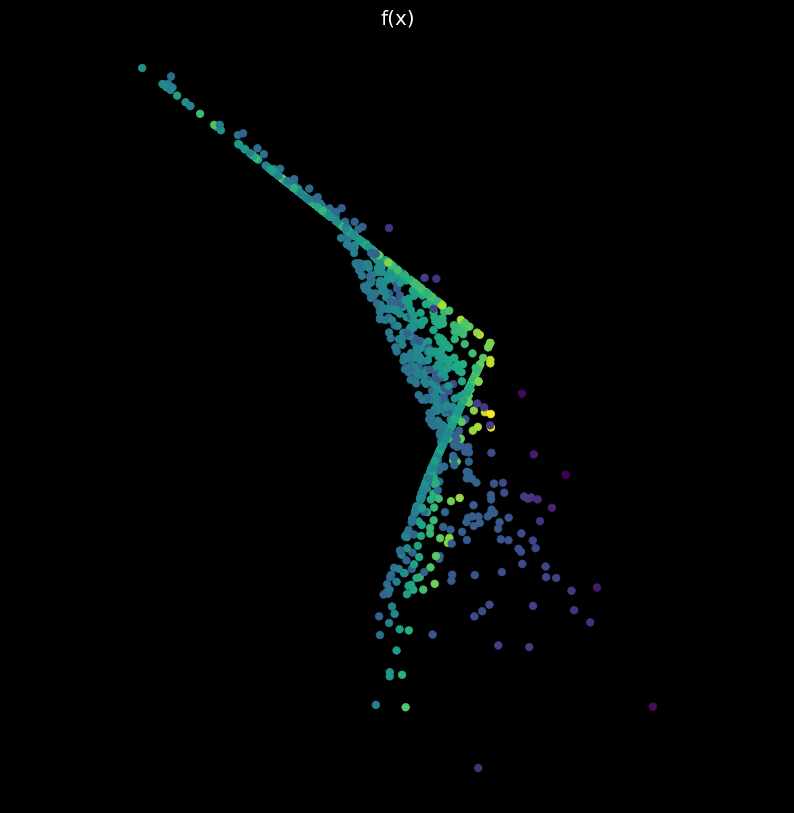

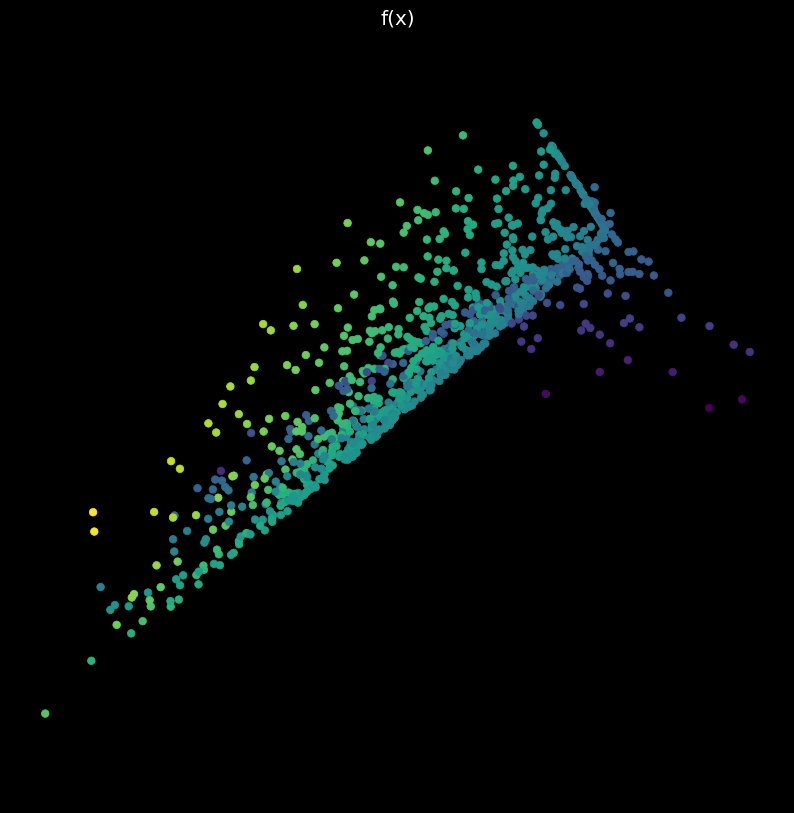

In [59]:
n_hidden = 5

NL = nn.ReLU()
# NL = nn.Tanh()

for i in range(2):
    # create 1-layer neural networks with random weights
    model = nn.Sequential(
            nn.Linear(2, n_hidden), 
            NL, 
            nn.Linear(n_hidden, 2)
        )
    model.to(device)
    with torch.no_grad():
        Y = model(X)
    show_scatterplot(Y, colors, title='f(x)')

--- Activation Function: ReLU ---


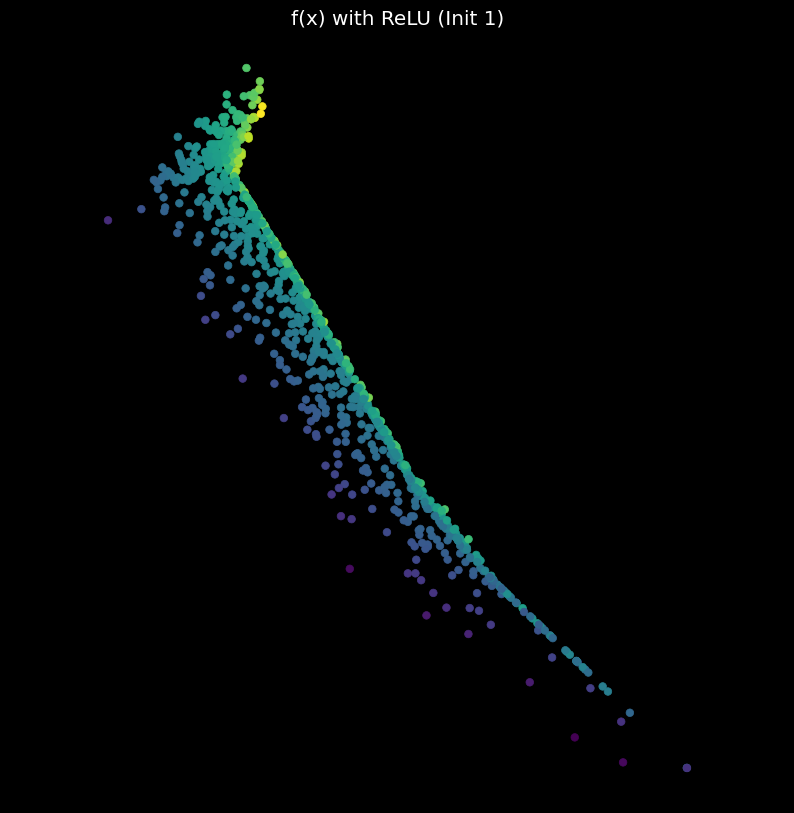

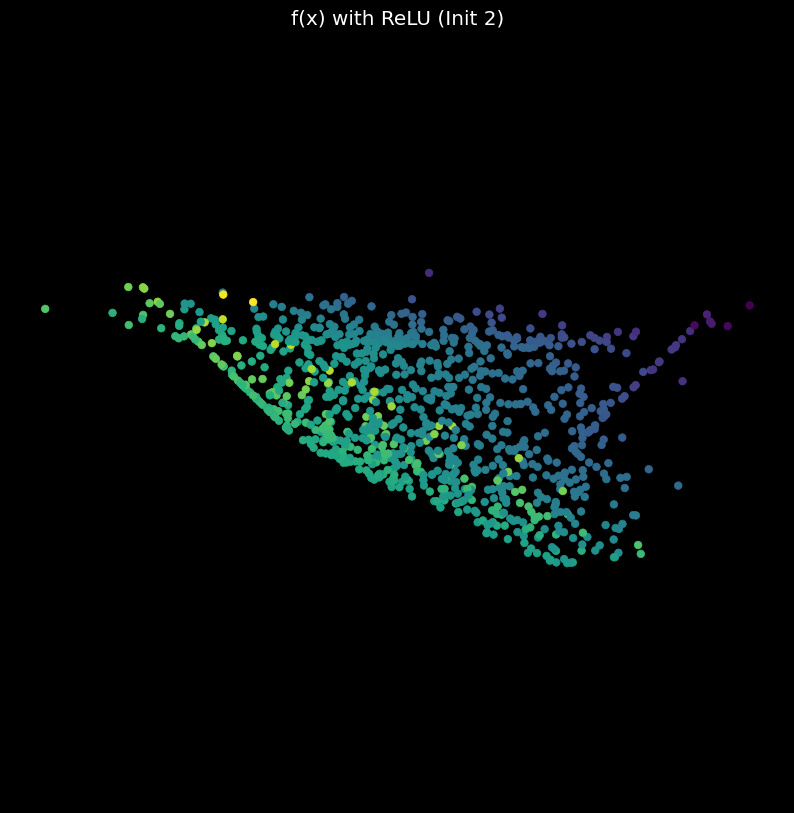

--- Activation Function: Tanh ---


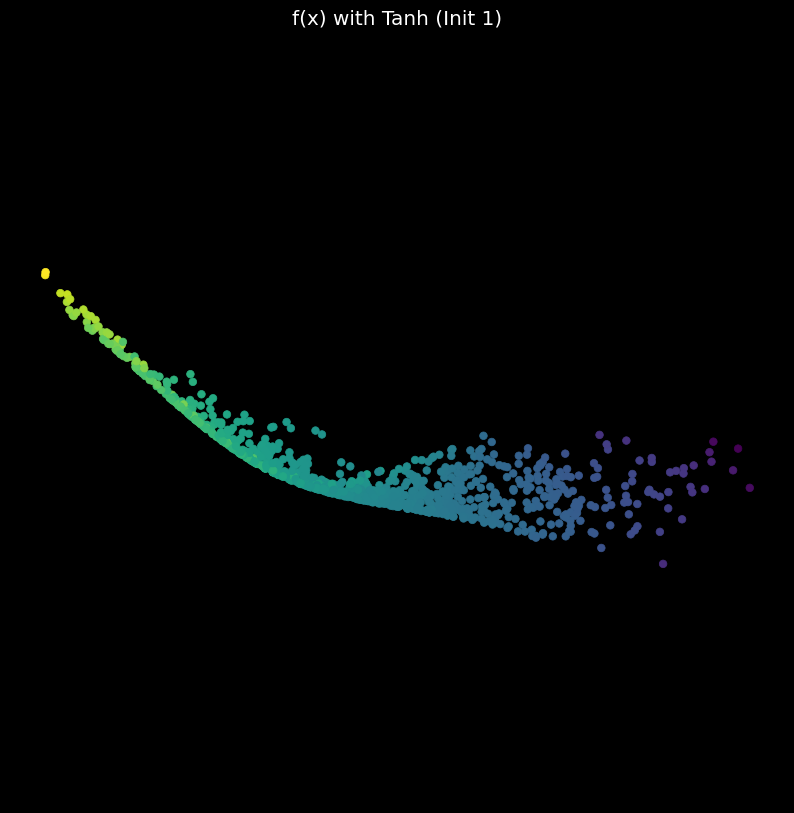

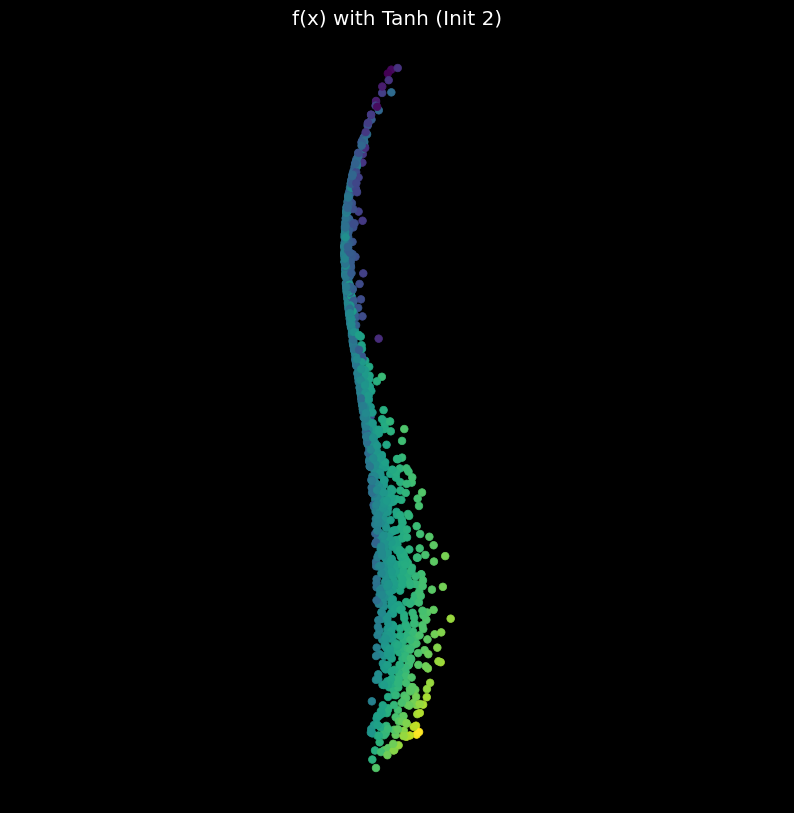

--- Activation Function: Sigmoid ---


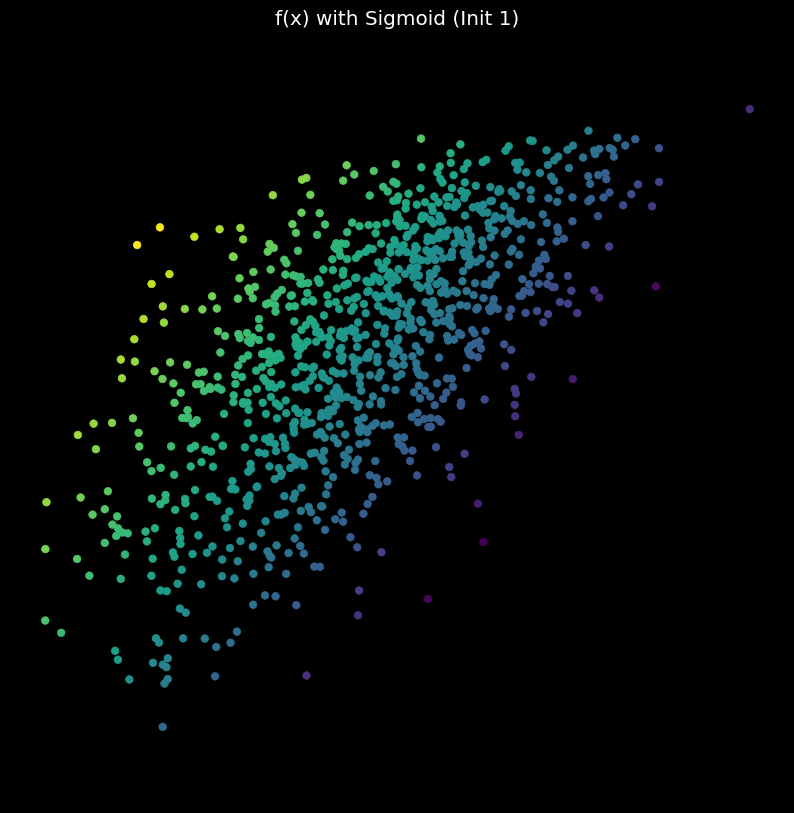

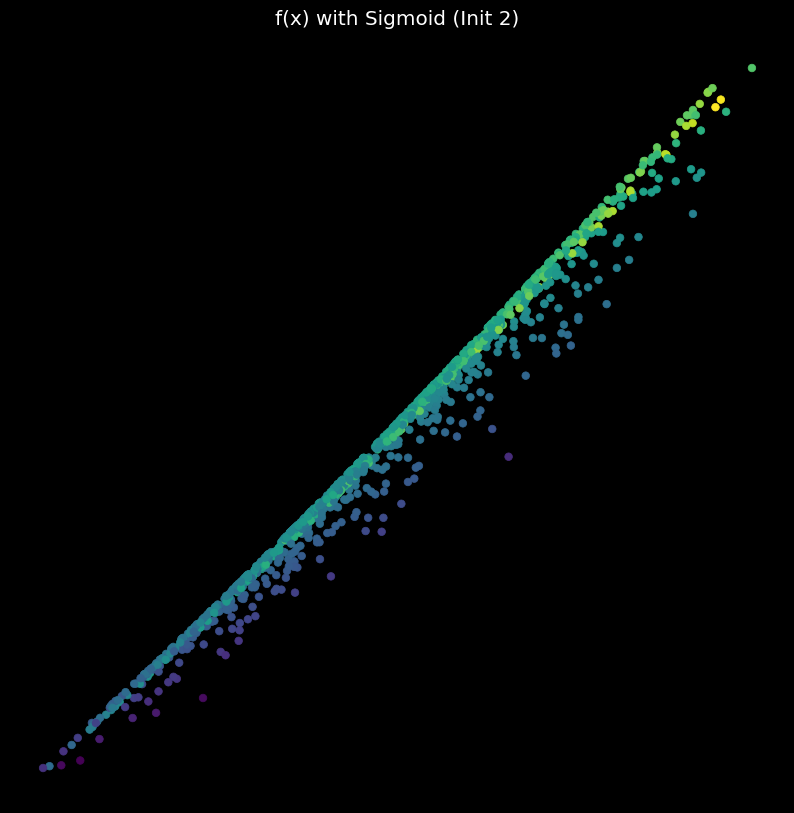

--- Activation Function: LeakyReLU ---


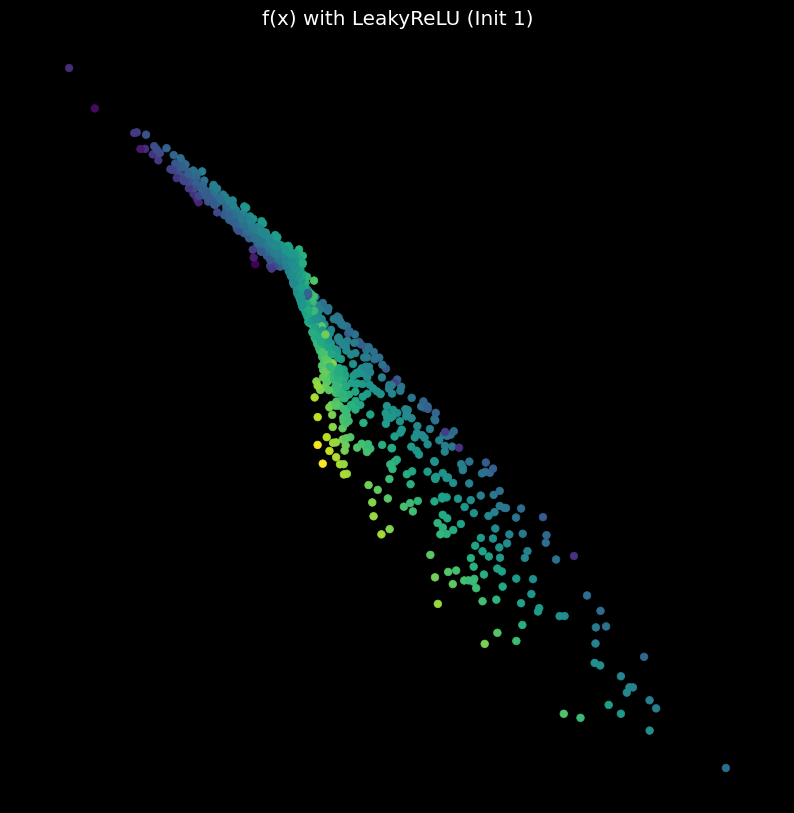

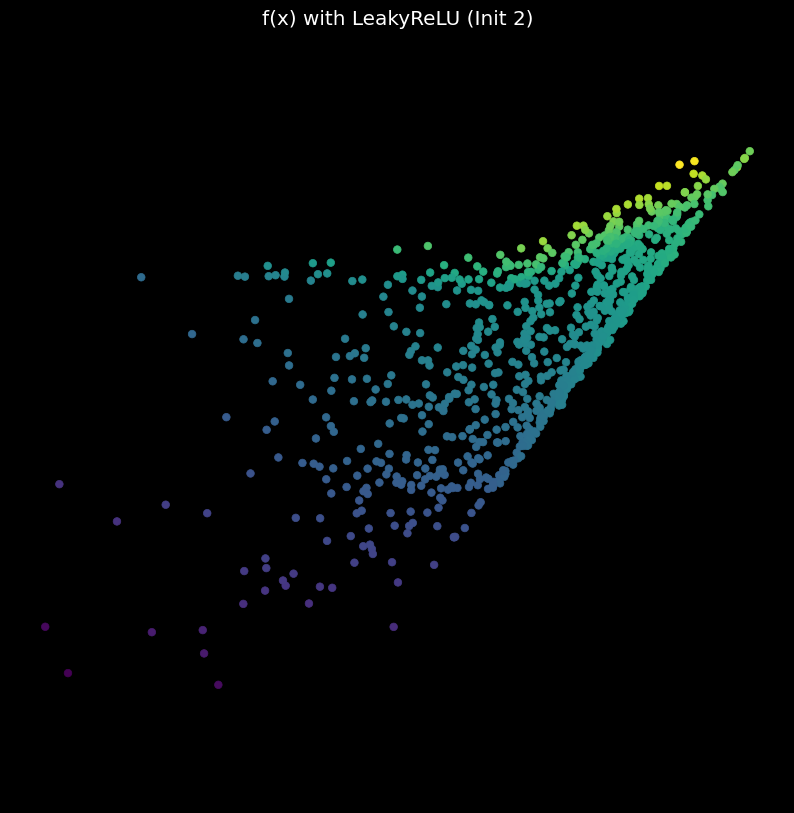

In [60]:
# --- Exercise: Change the activation function ---

import torch.nn as nn

n_hidden = 5
activations = {
    "ReLU": nn.ReLU(),
    "Tanh": nn.Tanh(),
    "Sigmoid": nn.Sigmoid(),
    "LeakyReLU": nn.LeakyReLU(0.1)
}

for name, NL in activations.items():
    print(f"--- Activation Function: {name} ---")
    for i in range(2): # Show 2 random initializations per activation
        model = nn.Sequential(
            nn.Linear(2, n_hidden), 
            NL, 
            nn.Linear(n_hidden, 2)
        )
        model.to(device)
        with torch.no_grad():
            Y = model(X)
        show_scatterplot(Y, colors, title=f'f(x) with {name} (Init {i+1})')
    # Use plt.show() to ensure figures are flushed before the next activation text
    import matplotlib.pyplot as plt
    plt.show()

### Train a simple Neural Network on sample data

In the following, we train a model and see how the data is modified.

The different steps are:
1. Build your model.
2. Build a DataLoader. This tells the computer how to read data (can be text, images, videos etc, ).
3. Build a training loop. Need to specify the how to update the model params each pass of the data. Loss, Regularisation, etc happens here.

In [61]:
seed = 12345
random.seed(seed)
torch.manual_seed(seed)
N = 1000  # num_samples_per_class
D = 2  # dimensions
C = 2  # num_classes
H = 100  # num_hidden_units

In [62]:
X = torch.zeros(N * C, D).to(device)
y = torch.zeros(N * C, dtype=torch.long).to(device)
for c in range(C):
    index = 0
    t = torch.linspace(0, 1, N)
    # When c = 0 and t = 0: start of linspace
    # When c = 0 and t = 1: end of linpace
    # This inner_var is for the formula inside sin() and cos() like sin(inner_var) and cos(inner_Var)
    inner_var = torch.linspace(
        # When t = 0
        (2 * math.pi / C) * (c),
        # When t = 1
        (2 * math.pi / C) * (2 + c),
        N
    ) + torch.randn(N) * 0.2
    
    for ix in range(N * c, N * (c + 1)):
        X[ix] = t[index] * torch.FloatTensor((
            math.sin(inner_var[index]), math.cos(inner_var[index])
        ))
        y[ix] = c
        index += 1

print("Shapes:")
print("X:", tuple(X.size()))
print("y:", tuple(y.size()))

Shapes:
X: (2000, 2)
y: (2000,)


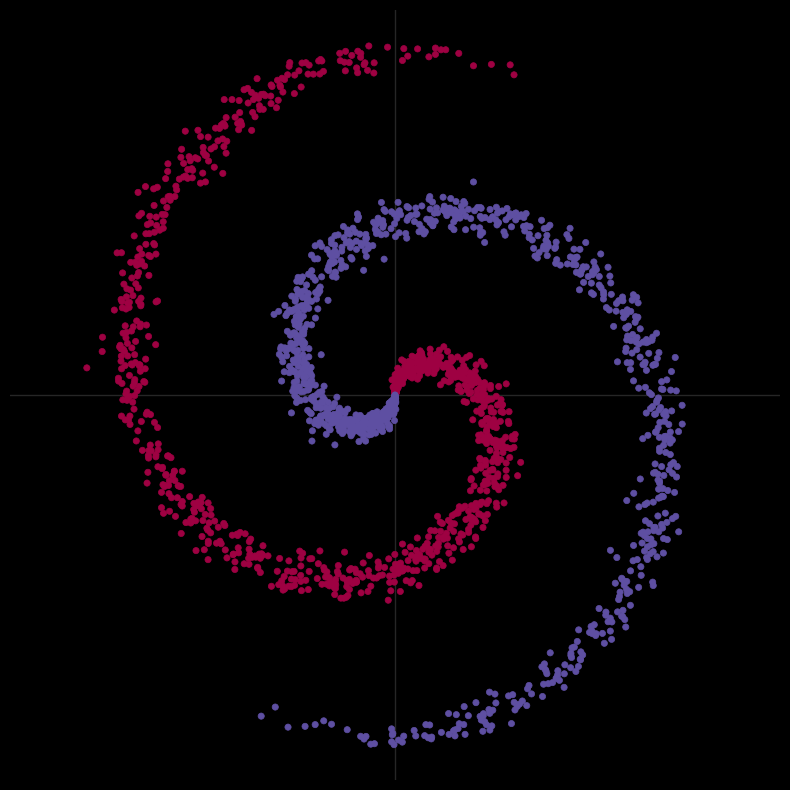

In [63]:
plot_data(X, y)

In [64]:
learning_rate = 1e-3
lambda_l2 = 1e-5 #this is for L2 regularisation

model = nn.Sequential(
    nn.Linear(D, H),
    nn.ReLU(),
    nn.Linear(H, C)
)
model.to(device)

# nn package also has different loss functions.
criterion = torch.nn.CrossEntropyLoss() # Most commonly used loss function in case of classification tasks.

# we use the optim sub-package to apply our parameter updates
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=lambda_l2) # built-in L2

# Training
for t in range(1000):
    
    # Feed forward to get the logits
    y_pred = model(X)
    
    # Compute the loss and accuracy
    loss = criterion(y_pred, y)
    score, predicted = torch.max(y_pred, 1)
    acc = (y == predicted).sum().float() / len(y)
    print("[EPOCH]: %i, [LOSS]: %.6f, [ACCURACY]: %.3f" % (t, loss.item(), acc))
    display.clear_output(wait=True)
    
    # zero the gradients before running
    # the backward pass.
    optimizer.zero_grad()
    
    # Backward pass to compute the gradient
    # of loss w.r.t our learnable params. 
    loss.backward()
    
    # Update params
    optimizer.step()

[EPOCH]: 999, [LOSS]: 0.116976, [ACCURACY]: 0.971


**Exercise:**
Investigate the performance of the model concerning its depth and width. Which performs better? 
Fatter Neural nets or Taller neural nets. Build multiple models with different number of neurons 
and hidden layer and report the result.

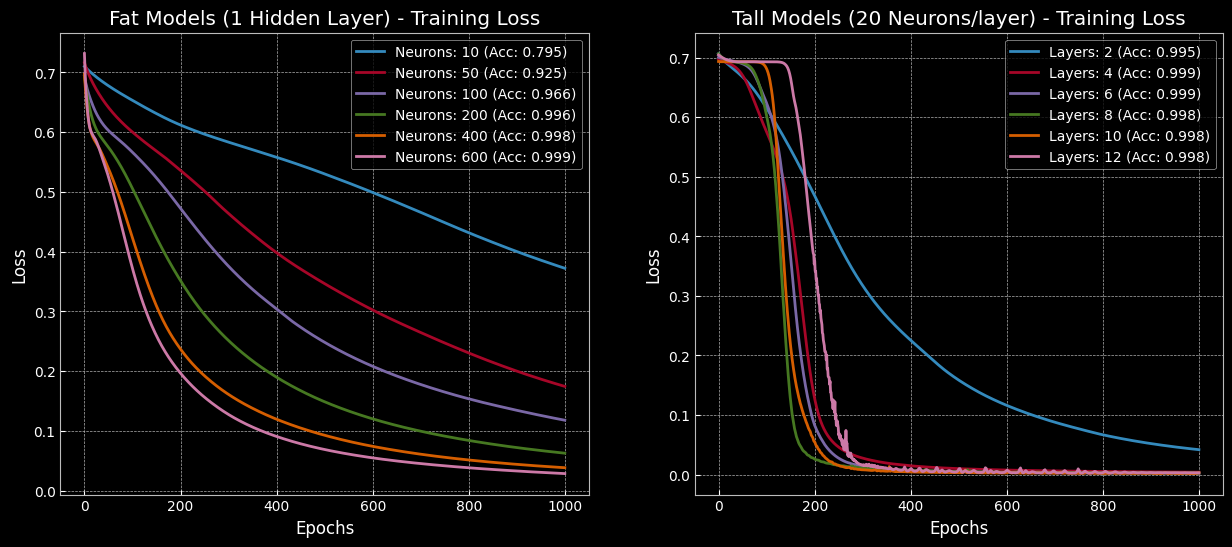

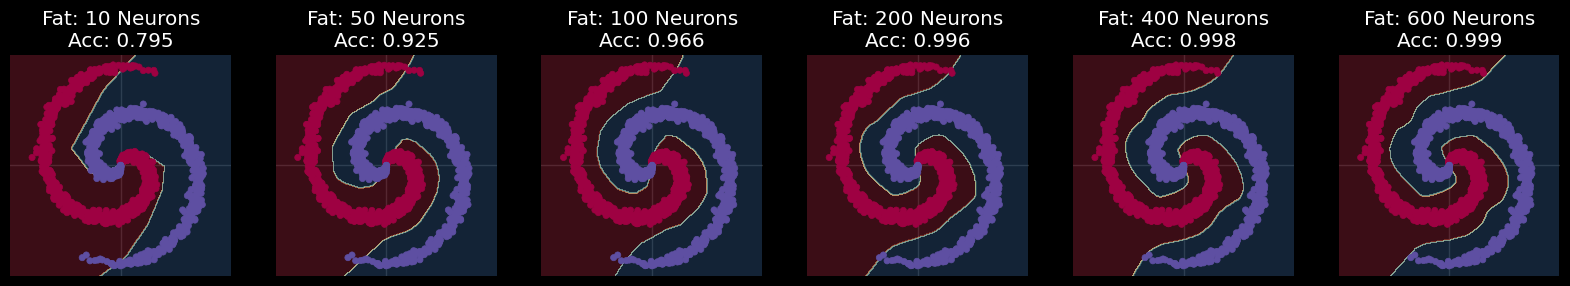

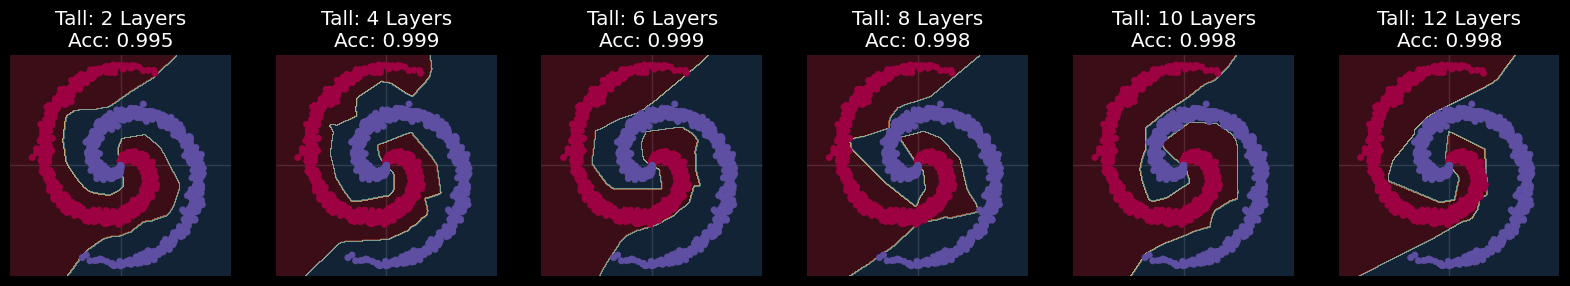

In [65]:
import matplotlib.pyplot as plt
from plot_lib import plot_model

def create_fat_model(n_neurons):
    return nn.Sequential(
        nn.Linear(D, n_neurons),
        nn.ReLU(),
        nn.Linear(n_neurons, C)
    )

def create_tall_model(n_layers, n_neurons=20):
    layers = [nn.Linear(D, n_neurons), nn.ReLU()]
    for _ in range(n_layers - 1):
        layers.extend([nn.Linear(n_neurons, n_neurons), nn.ReLU()])
    layers.append(nn.Linear(n_neurons, C))
    return nn.Sequential(*layers)

def train_model_with_tracking(model, X, y, epochs=1000, lr=1e-3, l2=1e-5):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2)
    losses = []
    
    for t in range(epochs):
        y_pred = model(X)
        loss = criterion(y_pred, y)
        losses.append(loss.item())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    with torch.no_grad():
        y_pred = model(X)
        _, predicted = torch.max(y_pred, 1)
        acc = (y == predicted).sum().float() / len(y)
    
    return acc.item(), losses

fat_configs = [10, 50, 100, 200, 400, 600]
tall_configs = [2, 4, 6, 8,10,12] # number of hidden layers

fat_results = {}
tall_results = {}

# Train Fat Models
for n in fat_configs:
    m = create_fat_model(n).to(device)
    acc, losses = train_model_with_tracking(m, X, y)
    fat_results[n] = {'model': m, 'acc': acc, 'losses': losses}

# Train Tall Models
for l in tall_configs:
    m = create_tall_model(l, 20).to(device)
    acc, losses = train_model_with_tracking(m, X, y)
    tall_results[l] = {'model': m, 'acc': acc, 'losses': losses}

# Visualization 1: Loss curves
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
for n in fat_configs:
    plt.plot(fat_results[n]['losses'], label=f'Neurons: {n} (Acc: {fat_results[n]["acc"]:.3f})')
plt.title('Fat Models (1 Hidden Layer) - Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
for l in tall_configs:
    plt.plot(tall_results[l]['losses'], label=f'Layers: {l} (Acc: {tall_results[l]["acc"]:.3f})')
plt.title('Tall Models (20 Neurons/layer) - Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Visualization 2: Decision Boundaries for Fat Models
plt.figure(figsize=(20, 5))
for i, n in enumerate(fat_configs):
    plt.subplot(1, len(fat_configs), i+1)
    plt.title(f'Fat: {n} Neurons\nAcc: {fat_results[n]["acc"]:.3f}')
    plot_model(X, y, fat_results[n]['model'])
plt.show()

# Visualization 3: Decision Boundaries for Tall Models
plt.figure(figsize=(20, 5))
for i, l in enumerate(tall_configs):
    plt.subplot(1, len(tall_configs), i+1)
    plt.title(f'Tall: {l} Layers\nAcc: {tall_results[l]["acc"]:.3f}')
    plot_model(X, y, tall_results[l]['model'])
plt.show()

Visualizing the learning process over epochs...


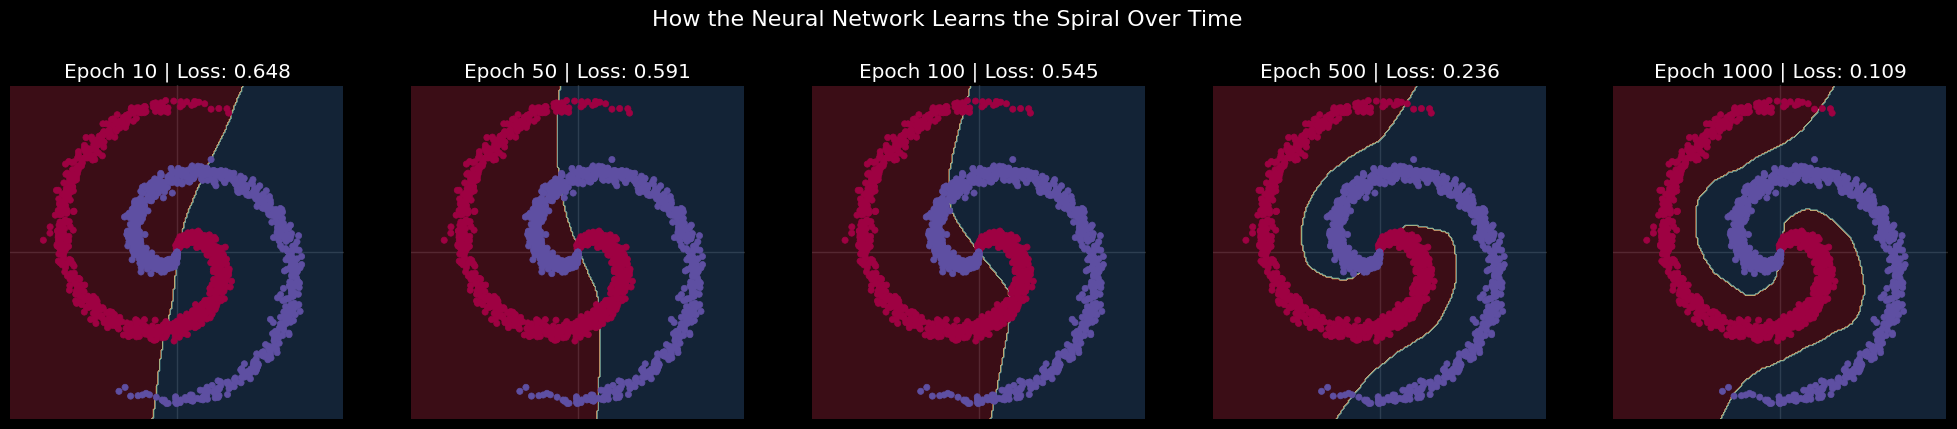

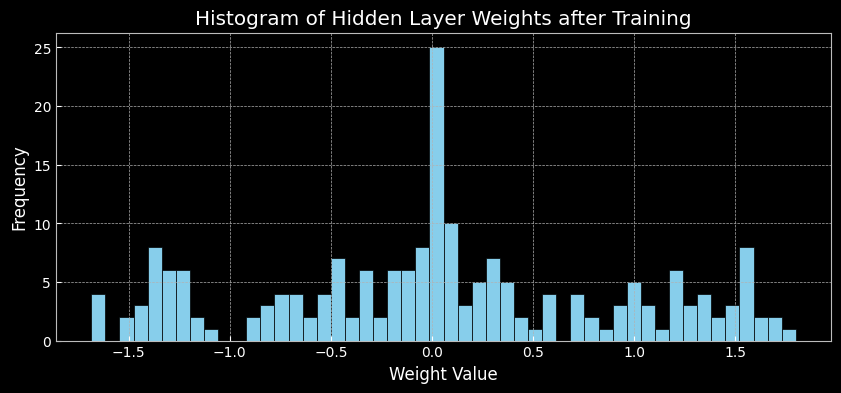

In [66]:
# --- Additional Visualizations to Understand Learning Over Time ---
import matplotlib.pyplot as plt
from plot_lib import plot_model
import torch.nn as nn

# Let's see how the decision boundary evolves as the model learns!
print("Visualizing the learning process over epochs...")

learning_rate = 1e-3
lambda_l2 = 1e-5
H = 100 # hidden units

# We create a fresh model
demo_model = nn.Sequential(
    nn.Linear(D, H),
    nn.ReLU(),
    nn.Linear(H, C)
)
demo_model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(demo_model.parameters(), lr=learning_rate, weight_decay=lambda_l2)

epochs_to_plot = [10, 50, 100, 500, 1000]

plt.figure(figsize=(25, 5))
plot_idx = 1

for t in range(1, 1001):
    y_pred = demo_model(X)
    loss = criterion(y_pred, y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if t in epochs_to_plot:
        plt.subplot(1, len(epochs_to_plot), plot_idx)
        plt.title(f'Epoch {t} | Loss: {loss.item():.3f}')
        plot_model(X, y, demo_model)
        plot_idx += 1

plt.suptitle("How the Neural Network Learns the Spiral Over Time", fontsize=16)
plt.show()

# Visualize the weights of the hidden layer
weights = demo_model[0].weight.detach().cpu().numpy()
plt.figure(figsize=(10, 4))
plt.hist(weights.flatten(), bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Hidden Layer Weights after Training')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.show()